# `pymathutils.mesh.HalfEdgeMesh` tests

### HalfEdgeMesh tests

## Split edges

Ne=1962, Nf=1308
flips=745
flips=60
flips=1
flips=0
flips=0
Ne=5886, Nf=3924
flips=2282
flips=165
flips=2
flips=0
flips=0
Ne=17658, Nf=11772
flips=6706
flips=534
flips=12
flips=0
flips=0


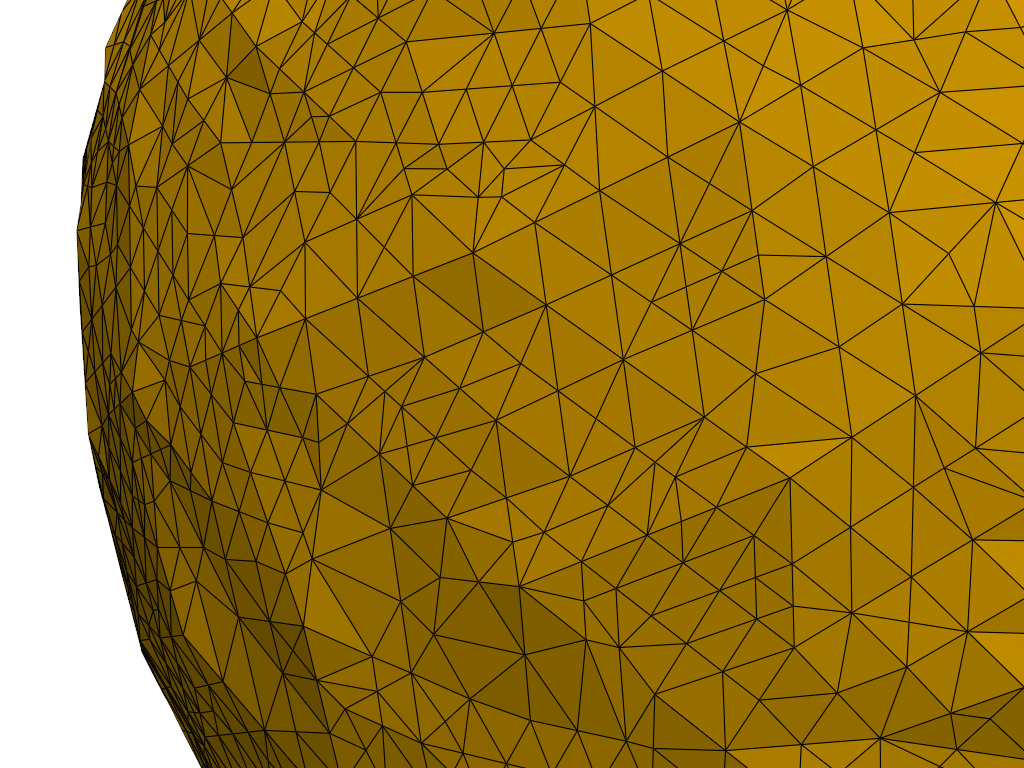

In [1]:
import sys
from pathlib import Path
import os
nb_dir = Path().resolve()
proj_dir = (nb_dir / "..").resolve()
sys.path.insert(0, str(proj_dir))
in_ply_dir = (proj_dir / "data" / "example_ply").resolve()
out_dir = (proj_dir / "output").resolve()
from pymathutils.mesh import HalfEdgeMesh
from src.python.mesh_viewer import MeshViewer
import numpy as np

# ply_path = f"{in_ply_dir}/plane_0000006_he.ply"
# ply_path = f"{in_ply_dir}/bunny.ply"


def plot_mesh(m):
    viewer_kwargs = {
        "image_dir": f"{out_dir}/next_cycle",
        "image_index_length": 6,
        "show_wireframe_surface": False,
        "show_face_colored_surface": True,
        "show_vertices": False,
        "show_half_edges": False,
        "rgba_face": (1.0, 0.7431, 0.0, 1.0),
        "rgba_edge": (0.0, 0.0, 0.0, 0.0),
        "rgba_half_edge": (0.5804, 0.0, 0.8275, 1.0),
        "rgb_background": (1, 1, 1),
        "view": {
            "azimuth": 0.0,
            "elevation": 90.0,
            "distance": 8.75,
            "focalpoint": (0, 1.0, 0),
        },
    }
    mv = MeshViewer(m, **viewer_kwargs)
    
    return mv.pv_plot(show=True, save=False,)

def plot_ply(inply):
    m = HalfEdgeMesh()
    m.load_ply(inply)
    return plot_mesh(m)
    
def get_rand_pert(m):
    return 0.75*(np.random.rand(m.X_ambient_V.shape[0]*m.X_ambient_V.shape[1]).reshape(m.X_ambient_V.shape)-0.5)/np.sqrt(m.topo.num_vertices())
    
def split_longest_edge_test():
    inply = f"{in_ply_dir}/dumbbell_coarse.ply"
    num_iter = 3
    m = HalfEdgeMesh()
    m.load_ply(inply)
    # m.X_ambient_V[:] += get_rand_pert(m)
    for _ in range(num_iter):
        Ne = m.topo.num_edges()
        Nf = m.topo.num_faces()
        print(f"{Ne=}, {Nf=}")
        F = np.random.permutation(range(Nf))
        for f in F:
            h0 = m.h_right_f(f)
            h1 = m.h_next_h(h0)
            h2 = m.h_next_h(h1)
            H = np.array([h0, h1, h2])
            E = np.array([m.e_undirected_h(h) for h in H])
            L = np.linalg.norm([m.X_ambient_v(m.topo.v_head_h(h))-m.X_ambient_v(m.v_origin_h(h)) for h in H], axis=1)
            I = np.argsort(L)
            H = H[I]
            E = E[I]
            L = L[I]
            # print(f"{L=}")
            e_max = E[-1]
            l_max = L[-1]
            m.split_edge(e_max)
            # m.split_edge(E[0])
            # m.split_edge(E[1])
            # m.split_edge(E[2])
        # m.X_ambient_V[:] += get_rand_pert(m)
        flips = m.flip_non_delaunay()
        print(f"{flips=}")
        flips = m.flip_non_delaunay()
        print(f"{flips=}")
        flips = m.flip_non_delaunay()
        print(f"{flips=}")
        flips = m.flip_non_delaunay()
        print(f"{flips=}")
        flips = m.flip_non_delaunay()
        print(f"{flips=}")
        m.refresh_simplex_cycles_from_topo()
    return plot_mesh(m)

def split_all_edge_test():
    inply = f"{in_ply_dir}/annulus_he.ply"
    m = HalfEdgeMesh()
    m.load_ply(inply)
    for _ in range(1):
        Ne = m.topo.num_edges()
        print(f"{Ne=}")
        for e in range(Ne):
            m.split_edge(e)
        m.refresh_simplex_cycles_from_topo()
    return plot_mesh(m)

def split_one_edge_test():
    inply = f"{in_ply_dir}/annulus_vf.ply"
    e = 7 # bad
    # e = 8 # ok
    m = HalfEdgeMesh()
    m.load_ply(inply)
    m.split_edge(e)
    m.split_edge(e)
    m.split_edge(e)
    m.split_edge(e)
    m.refresh_simplex_cycles_from_topo()
    return plot_mesh(m)
# p=split_one_edge_test()
# split_all_edge_test()
split_longest_edge_test()

In [1]:
import sys
from pathlib import Path
import os
nb_dir = Path().resolve()
proj_dir = (nb_dir / "..").resolve()
sys.path.insert(0, str(proj_dir))
in_ply_dir = (proj_dir / "data" / "example_ply").resolve()
out_dir = (proj_dir / "output").resolve()
from pymathutils.mesh import HalfEdgeMesh
from src.python.mesh_viewer import MeshViewer
import numpy as np

ply_path = f"{in_ply_dir}/annulus.ply"

def plot_mesh(m):
    viewer_kwargs = {
        "image_dir": f"{out_dir}/next_cycle",
        "image_index_length": 6,
        "show_wireframe_surface": False,
        "show_face_colored_surface": True,
        "show_vertices": False,
        "show_half_edges": False,
        "rgba_face": (1.0, 0.7431, 0.0, 1.0),
        "rgba_edge": (0.0, 0.0, 0.0, 0.0),
        "rgba_half_edge": (0.5804, 0.0, 0.8275, 1.0),
        "rgb_background": (1, 1, 1),
        "view": {
            "azimuth": 0.0,
            "elevation": 90.0,
            "distance": 8.75,
            "focalpoint": (0, 1.0, 0),
        },
    }
    mv = MeshViewer(m, **viewer_kwargs)
    
    return mv.pv_plot(show=True, save=False,)
m = HalfEdgeMesh()
m.load_ply(ply_path)

m0 = HalfEdgeMesh()
m0.load_ply(ply_path)

In [2]:
m.topo.num_boundaries()
m.topo.collapse_hedge(0)
# m.topo.collapse_hedge(0)
m.refresh_simplex_cycles_from_topo()
plot_mesh(m)

In [12]:
import sys
from pathlib import Path
import os
nb_dir = Path().resolve()
proj_dir = (nb_dir / "..").resolve()
sys.path.insert(0, str(proj_dir))
in_ply_dir = (proj_dir / "data" / "example_ply").resolve()
out_dir = (proj_dir / "output").resolve()
from pymathutils.mesh import HalfEdgeMesh
from src.python.mesh_viewer import MeshViewer
import numpy as np
inply = f"{in_ply_dir}/unit_sphere_005120.ply"
m = HalfEdgeMesh()
m.load_ply(inply)


In [15]:
m.topo.num_vertices()

2562